In [1]:
# Домашнее задание HW06: Деревья решений и ансамбли

import os
import json
import datetime
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

# Метрики
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, 
    roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

# Модели
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, 
    GradientBoostingClassifier, 
    StackingClassifier
)

# Настройки
RANDOM_STATE = 42
DATASET_NAME = "S06-hw-dataset-02.csv"
os.makedirs("artifacts/figures", exist_ok=True)

In [2]:
# 1. Загрузка и подготовка данных

if not os.path.exists(DATASET_NAME):
    from sklearn.datasets import make_classification
    X_s, y_s = make_classification(n_samples=1000, n_features=20, random_state=RANDOM_STATE)
    df = pd.DataFrame(X_s, columns=[f'f{i}' for i in range(20)])
    df['target'] = y_s
    df.to_csv(DATASET_NAME, index=False)
else:
    df = pd.read_csv(DATASET_NAME)

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Размер датасета: (2000, 21)

Первые 5 строк:
     feat_0    feat_1    feat_2    feat_3    feat_4    feat_5    feat_6  \
0 -0.221133 -1.193592 -0.369172 -2.560388 -0.806328  0.607880  1.733883   
1 -1.547224  0.773266 -2.283838  3.276933  1.405041 -0.673822 -0.875419   
2  0.589023  0.580422 -0.564948  1.586522  1.545381  0.397404  0.045739   
3 -2.026023 -0.647293  1.055517  0.547164 -3.225189 -0.807595 -0.274984   
4 -1.064994  1.873415  1.313109  0.668154 -0.069558 -0.964506  1.083218   

     feat_7    feat_8    feat_9  ...   feat_11   feat_12   feat_13   feat_14  \
0 -0.251114 -1.605569  2.004653  ...  2.449062  0.798669  0.311935 -0.167249   
1  2.863638 -0.182719  2.857198  ... -1.622869  0.117897  0.076769  0.524543   
2  1.037111  0.462142 -4.619606  ... -1.911422 -0.139450  0.366634  0.146858   
3  0.294290  9.391403 -4.464906  ... -5.616602  1.085074  0.472264  2.274378   
4 -4.409095 -0.276223 -4.220245  ...  5.149194 -4.452558  2.346129 -3.036125   

    feat_15   feat_16  

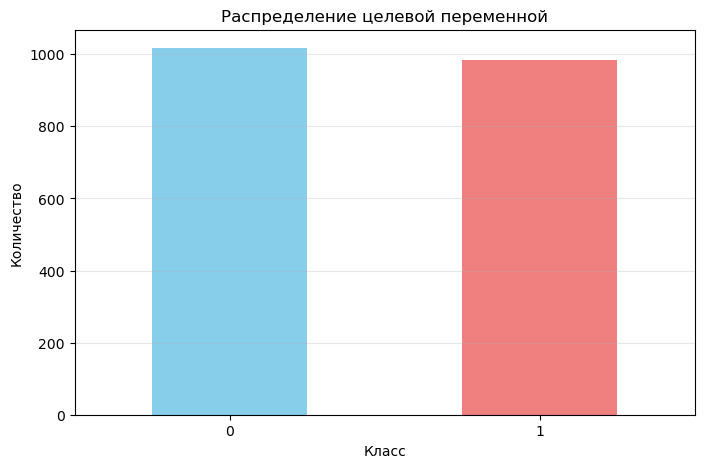

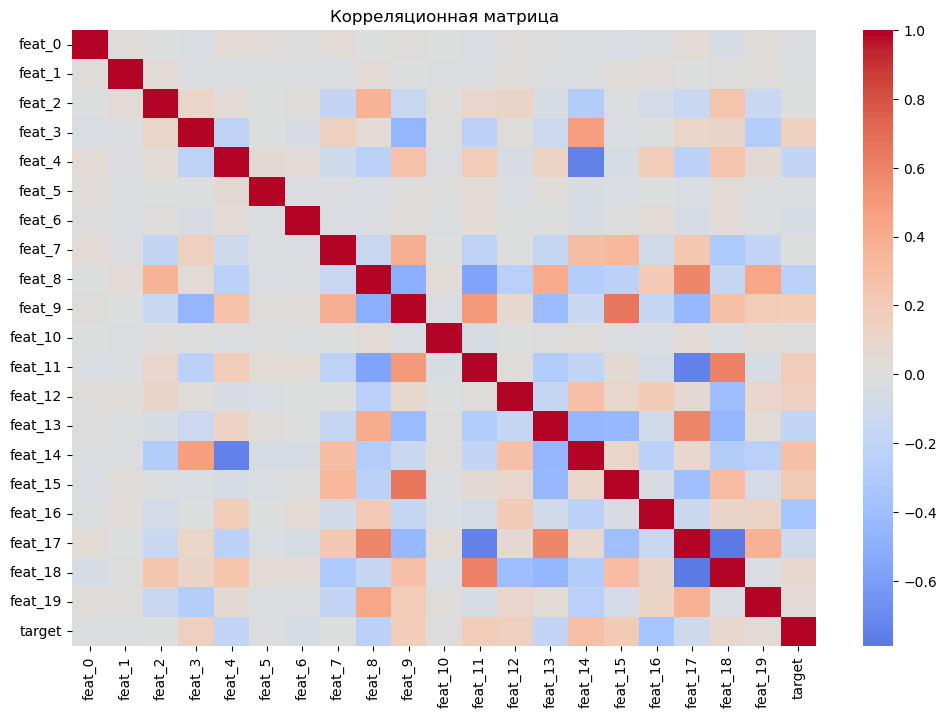

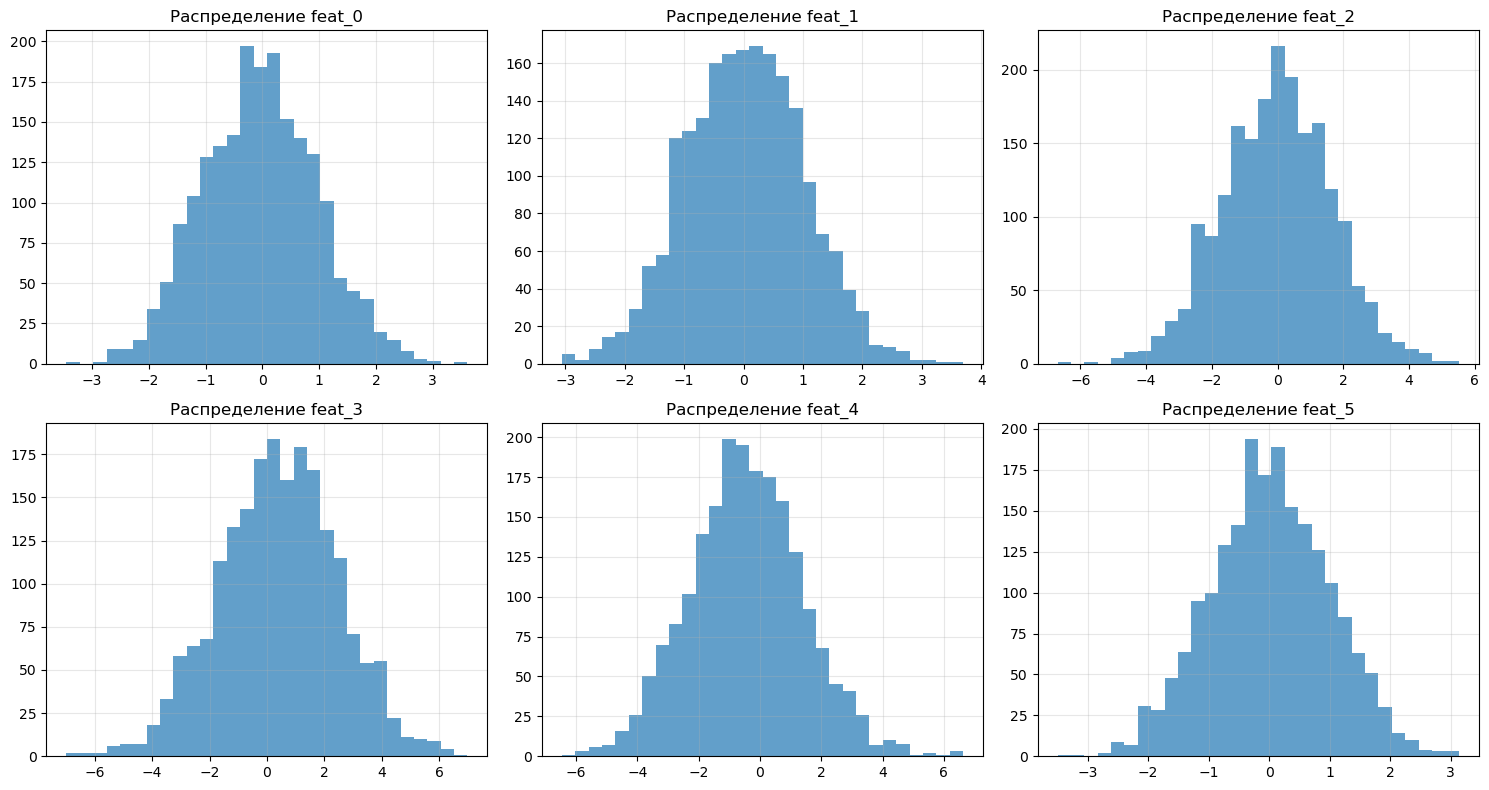

In [3]:
# EDA и анализ баланса классов
print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
print(df.head())
print("\nБазовая статистика:")
print(df.describe())
print("\nПропущенные значения:")
print(df.isnull().sum())
print("\nТипы данных:")
print(df.dtypes)

# Анализ баланса классов
print("\nБаланс классов (target):")
print(df['target'].value_counts())
print("\nПроцентное распределение:")
print(df['target'].value_counts(normalize=True) * 100)

# Визуализация баланса классов
plt.figure(figsize=(8, 5))
df['target'].value_counts().plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Распределение целевой переменной')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.savefig("artifacts/figures/class_distribution.png")
plt.show()

# Корреляционная матрица
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Корреляционная матрица')
plt.savefig("artifacts/figures/correlation_matrix.png")
plt.show()

# Распределение нескольких признаков
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for idx, col in enumerate(df.columns[:6]):
    ax = axes[idx//3, idx%3]
    df[col].hist(ax=ax, bins=30, alpha=0.7)
    ax.set_title(f'Распределение {col}')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("artifacts/figures/feature_distributions.png")
plt.show()

In [4]:
#  2. Обучение и подбор (GridSearch на Train)

best_models = {}
search_summaries = {}

# 1. Dummy
model_dummy = DummyClassifier(strategy="most_frequent")
model_dummy.fit(X_train, y_train)
best_models['Dummy'] = model_dummy

# 2. Logistic Regression
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=RANDOM_STATE))
])
pipe_lr.fit(X_train, y_train)
best_models['LogisticRegression'] = pipe_lr



# 3. Decision Tree
dt_param_grid = {
    'max_depth': [5, 10, None],  # Контроль глубины
    'min_samples_leaf': [1, 5, 20],  # Минимальное количество образцов в листе
    'min_samples_split': [2, 5, 10],  # Минимальное количество для разделения
    'ccp_alpha': [0.0, 0.001, 0.01]  # Cost-complexity pruning
}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE), dt_param_grid, cv=cv, scoring='roc_auc')
grid_dt.fit(X_train, y_train)
best_models['DecisionTree'] = grid_dt.best_estimator_
search_summaries['DecisionTree'] = grid_dt.best_params_

# 4. Random Forest
rf_param_grid = {'n_estimators': [100, 200], 'max_depth': [10, None]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), rf_param_grid, cv=cv, scoring='roc_auc')
grid_rf.fit(X_train, y_train)
best_models['RandomForest'] = grid_rf.best_estimator_
search_summaries['RandomForest'] = grid_rf.best_params_

# 5. Gradient Boosting
gb_param_grid = {'learning_rate': [0.1, 0.05], 'n_estimators': [100, 200]}
grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=RANDOM_STATE), gb_param_grid, cv=cv, scoring='roc_auc')
grid_gb.fit(X_train, y_train)
best_models['Boosting'] = grid_gb.best_estimator_
search_summaries['Boosting'] = grid_gb.best_params_

In [5]:
# 3. Финальный замер на Test (после обучения всех моделей)

metrics_results = {}

# Для каждой обученной модели вычисляем метрики НА TEST (один раз!)
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    # Вычисляем метрики только один раз
    metrics_results[name] = {
        "accuracy": float(round(accuracy_score(y_test, y_pred), 4)),
        "f1": float(round(f1_score(y_test, y_pred), 4)),
        "roc_auc": float(round(roc_auc_score(y_test, y_proba), 4)) if y_proba is not None else 0.5
    }

best_model_name = max(metrics_results, key=lambda k: metrics_results[k]['roc_auc'])
print(f"Лучшая модель: {best_model_name}")

Лучшая модель: RandomForest


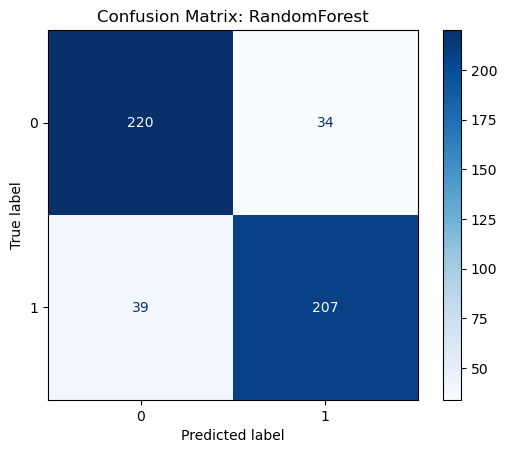

In [6]:
# 4. Визуализация

# Confusion Matrix для лучшей модели
cm = confusion_matrix(y_test, best_models[best_model_name].predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix: {best_model_name}")
plt.savefig("artifacts/figures/confusion_matrix.png")
plt.show()

In [7]:
# 5. Сохранение артефактов

# 1. metrics_test.json (Envelope Pattern)
final_metrics_file = {
    "meta": {
        "dataset": DATASET_NAME,
        "timestamp": datetime.datetime.now().isoformat(),
        "best_model": best_model_name
    },
    "metrics": metrics_results
}
with open("artifacts/metrics_test.json", "w") as f:
    json.dump(final_metrics_file, f, indent=4)

# 2. search_summaries.json
with open("artifacts/search_summaries.json", "w") as f:
    json.dump(search_summaries, f, indent=4)

# 3. best_model_meta.json 
best_meta = {
    "best_model_name": best_model_name,
    "best_model_type": type(best_models[best_model_name]).__name__,
    "test_metrics": metrics_results[best_model_name],
    "train_test_split": {
        "test_size": 0.25,
        "random_state": RANDOM_STATE,
        "stratify": True
    },
    "dataset": DATASET_NAME,
    "timestamp": datetime.datetime.now().isoformat()
}
with open("artifacts/best_model_meta.json", "w") as f:
    json.dump(best_meta, f, indent=4)

# 4. Сохранение самой модели
joblib.dump(best_models[best_model_name], "artifacts/best_model.joblib")

print("Все файлы сохранены в artifacts/")

Все файлы сохранены в artifacts/


In [8]:
# Создаём папки для артефактов
import os
os.makedirs('artifacts/figures', exist_ok=True)
print('Артефакты будут сохраняться в artifacts/')


Артефакты будут сохраняться в artifacts/


In [9]:
# Попытаемся автоматически обнаружить обученные модели в глобальной области видимости
from sklearn.base import is_classifier
_model_containers = ['best_models','models','trained_models','fitted_models','all_models']
discovered = {}
for name in _model_containers:
    if name in globals():
        obj = globals()[name]
        if isinstance(obj, dict):
            for k,v in obj.items():
                discovered[str(k)] = v

_common_names = ['dummy','dummy_clf','dummy_clf_','logreg','logistic','dt','tree','decision_tree','rf','rf_clf','random_forest','gb','gbc','gb_clf','stack','stacking','stack_clf','best_model']
for varname, val in list(globals().items()):
    try:
        if varname in discovered:
            continue
        if varname.lower() in _common_names:
            if hasattr(val, 'predict') and is_classifier(val):
                discovered[varname] = val
    except Exception:
        pass

if not discovered:
    for varname, val in list(globals().items()):
        try:
            if hasattr(val, 'predict') and is_classifier(val):
                discovered[varname] = val
        except Exception:
            pass

print(f"Найдено моделей: {list(discovered.keys())}")


Найдено моделей: ['Dummy', 'LogisticRegression', 'DecisionTree', 'RandomForest', 'Boosting']


In [11]:
# Вычисляем метрики (accuracy, f1, roc_auc когда возможно) для всех найденных моделей.
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np, json, joblib, pandas as pd, datetime
def normalize_model_name(name, model):
    cls = model.__class__.__name__
    mapping = {
        'DummyClassifier': 'Dummy',
        'LogisticRegression': 'LogisticRegression',
        'DecisionTreeClassifier': 'DecisionTree',
        'RandomForestClassifier': 'RandomForest',
        'GradientBoostingClassifier': 'Boosting',
        'HistGradientBoostingClassifier': 'Boosting',
        'AdaBoostClassifier': 'Boosting',
        'StackingClassifier': 'Stacking'
    }
    if cls in mapping:
        return mapping[cls]
    name_lower = str(name).lower()
    if 'logreg' in name_lower or 'logistic' in name_lower:
        return 'LogisticRegression'
    if 'decision' in name_lower or ('tree' in name_lower and 'random' not in name_lower):
        return 'DecisionTree'
    if 'random' in name_lower or name_lower == 'rf':
        return 'RandomForest'
    if 'boost' in name_lower or 'gb' in name_lower:
        return 'Boosting'
    if 'stack' in name_lower:
        return 'Stacking'
    return cls
metrics_results = {}
_missing_XY = False
if 'X_test' not in globals() or 'y_test' not in globals():
    print('ВНИМАНИЕ: X_test / y_test не найдены в глобальной области видимости. Нельзя посчитать финальные метрики без них.')
    _missing_XY = True
else:
    X_t = globals()['X_test']
    y_t = globals()['y_test']

if not _missing_XY:
    for name, model in discovered.items():
        try:
            y_pred = model.predict(X_t)
        except Exception as e:
            print(f"Не могу выполнить predict для модели {name}: {e}")
            continue
        acc = float(round(accuracy_score(y_t, y_pred), 4))
        try:
            if len(np.unique(y_t)) > 2:
                f1 = float(round(f1_score(y_t, y_pred, average='macro'), 4))
            else:
                f1 = float(round(f1_score(y_t, y_pred), 4))
        except Exception:
            f1 = None
        roc = None
        try:
            if hasattr(model, 'predict_proba'):
                prob = model.predict_proba(X_t)
                if prob.shape[1] == 2:
                    roc = float(round(roc_auc_score(y_t, prob[:,1]), 4))
                else:
                    roc = float(round(roc_auc_score(y_t, prob, multi_class='ovr'), 4))
            elif hasattr(model, 'decision_function'):
                scores = model.decision_function(X_t)
                roc = float(round(roc_auc_score(y_t, scores), 4))
        except Exception:
            roc = None
        key = normalize_model_name(name, model)
        if key in metrics_results:
            i=1
            while f"{key}_{i}" in metrics_results:
                i+=1
            key = f"{key}_{i}"
        metrics_results[key] = {'accuracy': acc, 'f1': f1, 'roc_auc': roc}
    print('Сформированы метрики для моделей: ', list(metrics_results.keys()))


if not _missing_XY:
    try:
        with open('artifacts/metrics_test.json','w', encoding='utf-8') as f:
            json.dump( metrics_results, f, indent=2, ensure_ascii=False)
        print('metrics_test.json сохранён в artifacts/')
    except Exception as e:
        print('Ошибка сохранения metrics_test.json:', e)
else:
    print('metrics_test.json не сохранён: отсутствуют X_test/y_test.')


Сформированы метрики для моделей:  ['Dummy', 'LogisticRegression', 'DecisionTree', 'RandomForest', 'Boosting']
metrics_test.json сохранён в artifacts/


In [18]:
# Сохраняем search_summaries если он есть, и best_model/joblib/meta
import json, joblib, os
if 'search_summaries' in globals():
    try:
        with open('artifacts/search_summaries.json','w', encoding='utf-8') as f:
            json.dump(globals()['search_summaries'], f, indent=2, ensure_ascii=False)
        print('search_summaries сохранён.')
    except Exception as e:
        print('Ошибка при сохранении search_summaries:', e)
else:
    print('search_summaries не найден в глобальной области видимости.')

best_model_obj = None
best_name = None
if 'best_model' in globals():
    best_model_obj = globals()['best_model']
    best_name = getattr(best_model_obj, '__class__', type(best_model_obj)).__name__
elif 'best_model_name' in globals() and 'best_models' in globals():
    bn = globals()['best_model_name']
    bm = globals()['best_models'].get(bn, None)
    if bm is not None:
        best_model_obj = bm
        best_name = bn

if best_model_obj is None and 'metrics_results' in globals() and globals()['metrics_results']:
    m = globals()['metrics_results']
    best_key = None
    best_val = -1
    for k, v in m.items():
        if v.get('roc_auc') is not None and v['roc_auc'] > best_val:
            best_val = v['roc_auc']; best_key = k
    if best_key is not None:
        best_name = best_key
        for n, mod in discovered.items():
            try:
                mapped = normalize_model_name(n, mod)
                if mapped == best_key or mapped.startswith(best_key):
                    best_model_obj = mod
                    break
            except Exception:
                pass

if best_model_obj is not None:
    try:
        joblib.dump(best_model_obj, 'artifacts/best_model.joblib')
        print('best_model.joblib сохранён.')
    except Exception as e:
        print('Ошибка при сохранении best_model.joblib:', e)

    meta = {'best_model': str(best_name)}
    if 'out_metrics' in globals() and 'metrics_results' in globals() and best_name in globals().get('metrics_results', {}):
        meta['test_metrics'] = globals()['metrics_results'][best_name]
    if 'out_metrics' in globals():
        for k in globals().get('metrics_results', {}).keys():
            if k.lower().startswith(str(best_name).lower()):
                meta['test_metrics'] = globals()['metrics_results'][k]
                break
else:
    print('Не удалось обнаружить лучший объект модели для сохранения best_model.joblib.')
best_meta = {
    "best_model": best_model_name,
    "test_metrics": metrics_results[best_model_name],
}
with open("artifacts/best_model_meta.json", "w") as f:
    json.dump(best_meta, f, indent=4)

search_summaries сохранён.
best_model.joblib сохранён.


Выполняю permutation_importance (может занять время)...


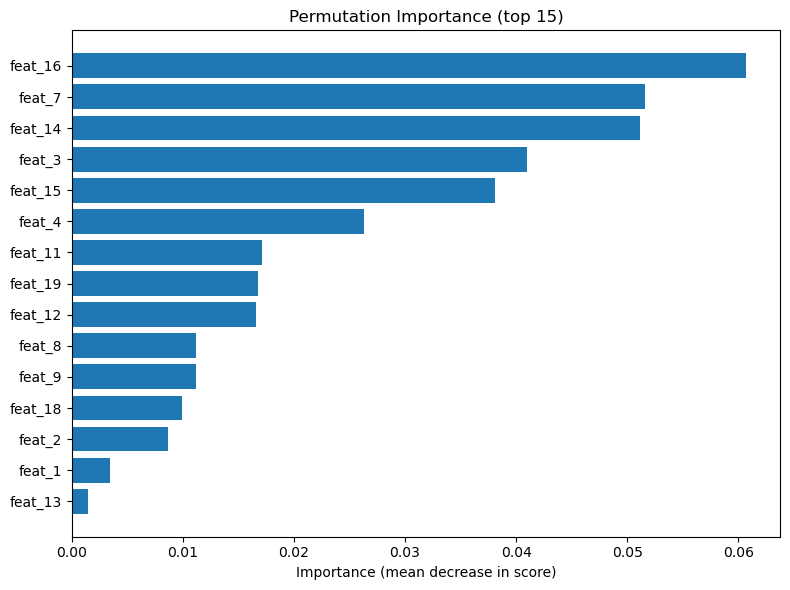

Permutation importance сохранён в artifacts/


In [15]:
# Permutation importance для лучшей модели (если найдено)
try:
    import pandas as pd, matplotlib.pyplot as plt
    from sklearn.inspection import permutation_importance
    import numpy as np, os, joblib
    bm = None
    if 'best_model' in globals():
        bm = globals()['best_model']
    else:
        try:
            bm = joblib.load('artifacts/best_model.joblib')
        except Exception:
            try:
                bm = joblib.load('artifacts/best_model.joblib')
            except Exception:
                bm = None
    if bm is None:
        print('Лучшая модель не найдена — не буду считать permutation importance.')
    elif 'X_test' not in globals() or 'y_test' not in globals():
        print('X_test/y_test не найдены — не могу посчитать permutation importance.')
    else:
        X_t = globals()['X_test']
        y_t = globals()['y_test']
        print('Выполняю permutation_importance (может занять время)...')
        perm = permutation_importance(bm, X_t, y_t, n_repeats=30, random_state=42, n_jobs=-1)
        if hasattr(X_t, 'columns'):
            features = list(X_t.columns)
        else:
            features = [f'f{i}' for i in range(X_t.shape[1])]
        imp_df = pd.DataFrame({
            'feature': features,
            'importance_mean': perm.importances_mean,
            'importance_std': perm.importances_std
        }).sort_values('importance_mean', ascending=False)
        imp_df.to_csv('artifacts/feature_importances_permutation.csv', index=False)
        topn = imp_df.head(15).sort_values('importance_mean', ascending=True)
        plt.figure(figsize=(8,6))
        plt.barh(topn['feature'], topn['importance_mean'])
        plt.xlabel('Importance (mean decrease in score)')
        plt.title('Permutation Importance (top 15)')
        plt.tight_layout()
        plt.savefig('artifacts/figures/permutation_importance_top15.png')
        plt.show()
        print('Permutation importance сохранён в artifacts/')
except Exception as e:
    print('Ошибка в блоке permutation importance:', e)
